# Customer Churn — Deep Analysis

Monthly account/membership churn across car-wash operators.

**Dataset:** `customer-churn/data/customer_churn.csv` — one row per *location × month*.

| field | meaning |
|---|---|
| `location_id`, `location_name` | site identifiers (`location_id` is **reused across operators**) |
| `source_schema` | operator / brand the location belongs to |
| `month`, `bucket_date` | reporting month |
| `accounts_start`, `accounts_end` | billing accounts at start / end of month |
| `deactivated_accounts` | accounts cancelled during the month |
| `active_members` | active members (vehicles/plans — a superset of accounts) |
| `new_signups` | accounts added during the month |
| `churn_rate_accounts`, `churn_rate_members` | pre-computed monthly churn % |

This notebook profiles the data, validates its internal accounting, builds a **volume-weighted** churn metric (the raw rates are badly outlier-contaminated), and surfaces actionable patterns: seasonality, the location "honeymoon" effect, growth-stage dynamics, operator benchmarking, and the scale–churn relationship.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('../data/customer_churn.csv')
df['bucket_date'] = pd.to_datetime(df['bucket_date'])

# location_id is reused across operators -> the real site key is operator + name
df['key'] = df['source_schema'] + ' | ' + df['location_name']
df['year'] = df['bucket_date'].dt.year
df['cal_month'] = df['bucket_date'].dt.month
df = df.sort_values(['key', 'bucket_date']).reset_index(drop=True)
df['tenure'] = df.groupby('key').cumcount()  # months since first appearance

print(f'{len(df):,} rows  |  {df["key"].nunique():,} locations  |  '
      f'{df["source_schema"].nunique()} operators')
print(f'Date range: {df.bucket_date.min():%Y-%m} -> {df.bucket_date.max():%Y-%m}')
df.head()

11,500 rows  |  514 locations  |  47 operators
Date range: 2017-03 -> 2026-06


,location_id,location_name,month,bucket_date,accounts_start,accounts_end,deactivated_accounts,active_members,churn_rate_accounts,churn_rate_members,new_signups,source_schema,key,year,cal_month,tenure
0,DEF,Alpine Wash,Jan-19,2019-01-01,1,1,0,1,0.00,0.00,0,alpine_wash_llc,alpine_wash_llc | Alpine Wash,2019,1,0
1,DEF,Alpine Wash,Feb-19,2019-02-01,1,73,0,83,0.00,0.00,72,alpine_wash_llc,alpine_wash_llc | Alpine Wash,2019,2,1
2,DEF,Alpine Wash,Mar-19,2019-03-01,73,271,13,309,17.81,15.66,211,alpine_wash_llc,alpine_wash_llc | Alpine Wash,2019,3,2
3,DEF,Alpine Wash,Apr-19,2019-04-01,271,345,29,401,10.70,9.39,102,alpine_wash_llc,alpine_wash_llc | Alpine Wash,2019,4,3
4,DEF,Alpine Wash,May-19,2019-05-01,345,412,32,473,9.28,8.48,99,alpine_wash_llc,alpine_wash_llc | Alpine Wash,2019,5,4


## 1. Data quality & structure

Two structural facts matter before any analysis:
1. `location_id` is **not** a unique key — the same id is reused by different operators. The dependable site key is `source_schema | location_name`.
2. `active_members` > `accounts_end` in most rows — **members and accounts are different units** (one account can cover several member vehicles/plans). Churn here is an *account* concept.

In [13]:
print('Nulls per column:')
print(df.isnull().sum()[lambda s: s > 0])

print(f'\nlocation_id values: {df.location_id.nunique()}  '
      f'but unique (operator,name) sites: {df.key.nunique()}')
reused = df.groupby('location_id')['source_schema'].nunique()
print(f'location_ids shared by >1 operator: {(reused > 1).sum()}')

print(f'\nRows where active_members > accounts_end: '
      f'{(df.active_members > df.accounts_end).mean():.0%}  '
      f'(members are a superset of accounts)')
print(f'corr(accounts_end, active_members) = '
      f'{df.accounts_end.corr(df.active_members):.3f}')

Nulls per column:
churn_rate_accounts    572
churn_rate_members     620
dtype: int64

location_id values: 431  but unique (operator,name) sites: 514
location_ids shared by >1 operator: 37

Rows where active_members > accounts_end: 58%  (members are a superset of accounts)
corr(accounts_end, active_members) = 0.987


In [14]:
# Validate the pre-computed churn formula: churn_rate_accounts == deactivated / accounts_start
chk = df.dropna(subset=['churn_rate_accounts']).copy()
chk['recomputed'] = 100 * chk.deactivated_accounts / chk.accounts_start.replace(0, np.nan)
print(f'corr(reported churn, recomputed) = {chk.recomputed.corr(chk.churn_rate_accounts):.4f}')
print('-> churn_rate_accounts = 100 * deactivated_accounts / accounts_start (confirmed)\n')

# Flow identity: accounts_end should == accounts_start + new_signups - deactivated
df['flow_resid'] = df.accounts_end - (df.accounts_start + df.new_signups - df.deactivated_accounts)
print(f'Flow identity (end = start + signups - deactivated) holds in '
      f'{(df.flow_resid == 0).mean():.0%} of rows')
print(f'Mean residual = {df.flow_resid.mean():+.1f}  '
      f'(positive -> reactivations / transfers / mid-month restatements not captured by signups)')

corr(reported churn, recomputed) = 1.0000
-> churn_rate_accounts = 100 * deactivated_accounts / accounts_start (confirmed)

Flow identity (end = start + signups - deactivated) holds in 66% of rows
Mean residual = +43.4  (positive -> reactivations / transfers / mid-month restatements not captured by signups)


**Takeaway:** the churn formula is verified, but the simple account-flow identity only holds ~66% of the time and the residual is *positive on average* — accounts appear that aren't explained by `new_signups` (reactivations, plan transfers, or restated balances). Treat single-row deltas with care; trust aggregates.

## 2. Why the raw churn rate is misleading

The pre-computed `churn_rate_accounts` has a mean of ~48% but a **median of 8%** — it is wrecked by tiny locations (e.g. `accounts_start = 1`, one cancellation gives 100%+ churn). The correct headline metric is **volume-weighted churn** = sum(deactivated) / sum(accounts_start).

In [15]:
def wchurn(g):
    """Volume-weighted monthly churn %: total deactivations / total starting accounts."""
    s = g.accounts_start.sum()
    return 100 * g.deactivated_accounts.sum() / s if s else np.nan

print('Raw churn_rate_accounts distribution:')
print(df.churn_rate_accounts.describe(percentiles=[.25, .5, .75, .9, .99]).round(2))
print(f'\nRows with churn > 100% (small-N artefacts): {(df.churn_rate_accounts > 100).sum()}')
print(f'\n>>> Volume-weighted overall monthly churn = {wchurn(df):.2f}%  '
      f'(~{100*(1-(1-wchurn(df)/100)**12):.0f}% annualized)')

Raw churn_rate_accounts distribution:
count   10,928.00
mean        47.77
std        844.02
min          0.00
25%          4.64
50%          8.01
75%         11.86
90%         17.77
99%        400.00
max     62,800.00
Name: churn_rate_accounts, dtype: float64

Rows with churn > 100% (small-N artefacts): 174

>>> Volume-weighted overall monthly churn = 9.42%  (~70% annualized)


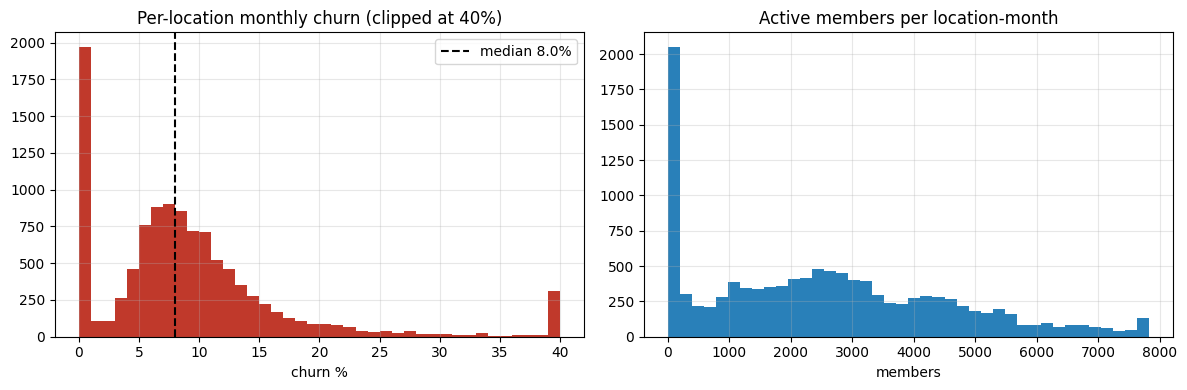

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.churn_rate_accounts.clip(upper=40).hist(bins=40, ax=ax[0], color='#c0392b')
ax[0].axvline(df.churn_rate_accounts.median(), color='k', ls='--',
              label=f'median {df.churn_rate_accounts.median():.1f}%')
ax[0].set(title='Per-location monthly churn (clipped at 40%)', xlabel='churn %'); ax[0].legend()

df.active_members.clip(upper=df.active_members.quantile(.99)).hist(bins=40, ax=ax[1], color='#2980b9')
ax[1].set(title='Active members per location-month', xlabel='members')
plt.tight_layout(); plt.show()

## 3. Seasonality — is there a churn season?

The *raw* monthly averages suggest huge summer spikes, but those are the same small-location outliers. On a **volume-weighted** basis churn is remarkably flat (~8.4–10.1% every month) — there is **no meaningful churn season**. Signups, by contrast, do show a spring/late-summer rhythm.

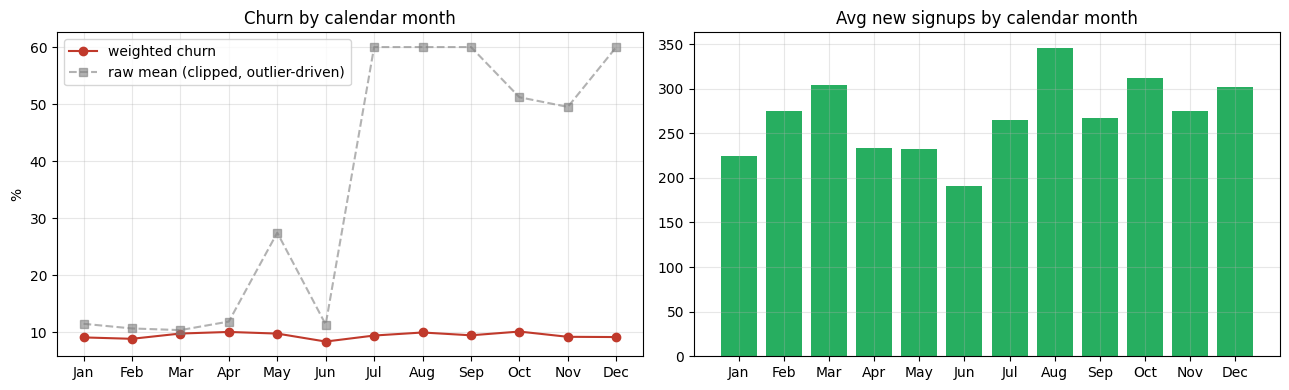

Weighted churn range across months: 8.39% - 10.14%  (spread of only 1.8pp)


In [17]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seas = df.groupby('cal_month').apply(wchurn, include_groups=False)
raw_seas = df.groupby('cal_month')['churn_rate_accounts'].mean()
signups = df.groupby('cal_month')['new_signups'].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(month_names, seas.values, 'o-', color='#c0392b', label='weighted churn')
ax[0].plot(month_names, raw_seas.clip(upper=60).values, 's--', color='gray', alpha=.6,
           label='raw mean (clipped, outlier-driven)')
ax[0].set(title='Churn by calendar month', ylabel='%'); ax[0].legend()
ax[1].bar(month_names, signups.values, color='#27ae60')
ax[1].set(title='Avg new signups by calendar month')
plt.tight_layout(); plt.show()
print('Weighted churn range across months: '
      f'{seas.min():.2f}% - {seas.max():.2f}%  (spread of only {seas.max()-seas.min():.1f}pp)')

## 4. The location "honeymoon" effect

Aligning every location to its own opening month reveals a clear lifecycle: churn is **lowest right after opening (~8%)**, climbs to a **peak around months 3–5 (~11%)** as the launch-promo cohort lapses, then settles near ~10% and eases at maturity. New sites look deceptively sticky in their first two months.

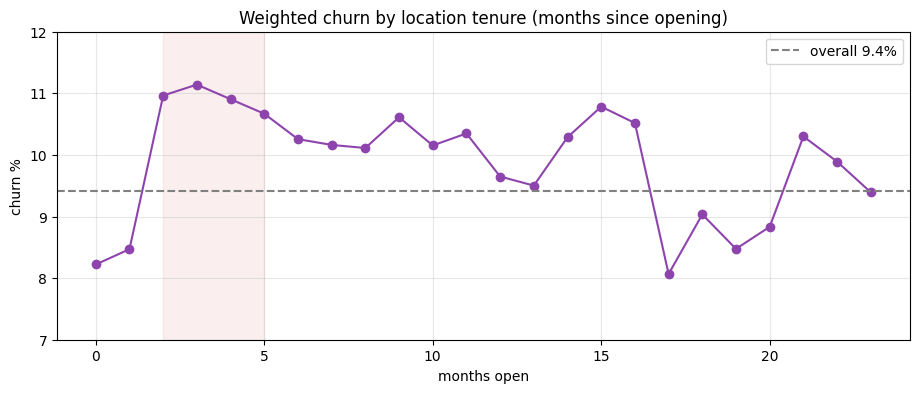

Tenure 0-1 (honeymoon): 8.36% | tenure 3-5 (peak): 10.89%


In [18]:
ten = df[df.tenure < 24].groupby('tenure').apply(wchurn, include_groups=False)
plt.figure(figsize=(11, 4))
plt.plot(ten.index, ten.values, 'o-', color='#8e44ad')
plt.axhline(wchurn(df), color='gray', ls='--', label=f'overall {wchurn(df):.1f}%')
plt.fill_between([2, 5], 7, 12, color='#c0392b', alpha=.08)
plt.title('Weighted churn by location tenure (months since opening)')
plt.xlabel('months open'); plt.ylabel('churn %'); plt.legend(); plt.ylim(7, 12)
plt.show()
print('Tenure 0-1 (honeymoon):', f'{wchurn(df[df.tenure<2]):.2f}%',
      '| tenure 3-5 (peak):', f'{wchurn(df[df.tenure.between(3,5)]):.2f}%')

## 5. Growth stage & retention trend over time

The portfolio scaled explosively (active members grew from a few thousand in 2019 to **>13M in 2025**). Churn was low (4–5%) in the early small-base years, spiked to **12.6% in 2023** during the steepest acquisition phase, and has since stabilized around **9%** — evidence the business moved past its hardest-to-retain growth-burst cohorts.

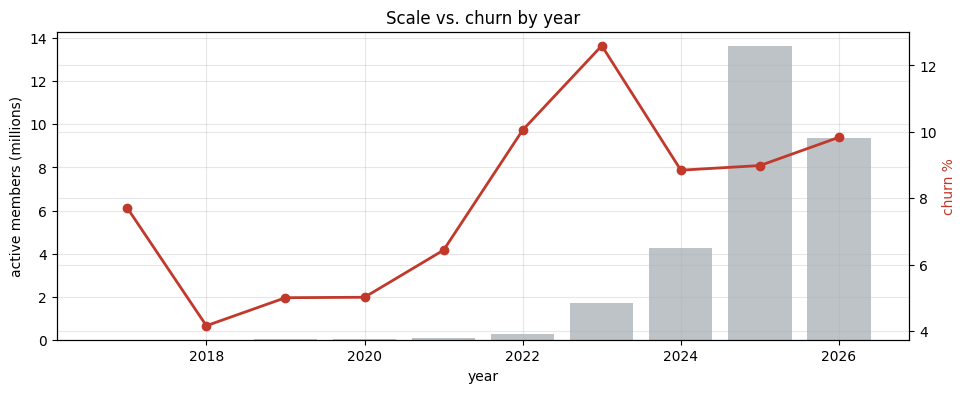

year
2017    7.70
2018    4.16
2019    5.00
2020    5.02
2021    6.44
2022   10.05
2023   12.59
2024    8.84
2025    8.98
2026    9.84


In [19]:
yr = df.groupby('year').apply(wchurn, include_groups=False)
members = df.groupby('year')['active_members'].sum()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(members.index, members.values/1e6, color='#bdc3c7', label='active members (M)')
ax1.set_ylabel('active members (millions)')
ax2 = ax1.twinx()
ax2.plot(yr.index, yr.values, 'o-', color='#c0392b', lw=2, label='weighted churn %')
ax2.set_ylabel('churn %', color='#c0392b')
ax1.set_title('Scale vs. churn by year'); ax1.set_xlabel('year')
plt.show()
print(yr.round(2).to_string())

## 6. Operator benchmarking

Volume-weighted churn by operator (>=5,000 cumulative starting accounts, so the ranking isn't noise). The spread is enormous: the best operators retain at **<6% monthly churn** while the worst bleed **>20%** — a difference that compounds to the entire lifetime value of a membership base.

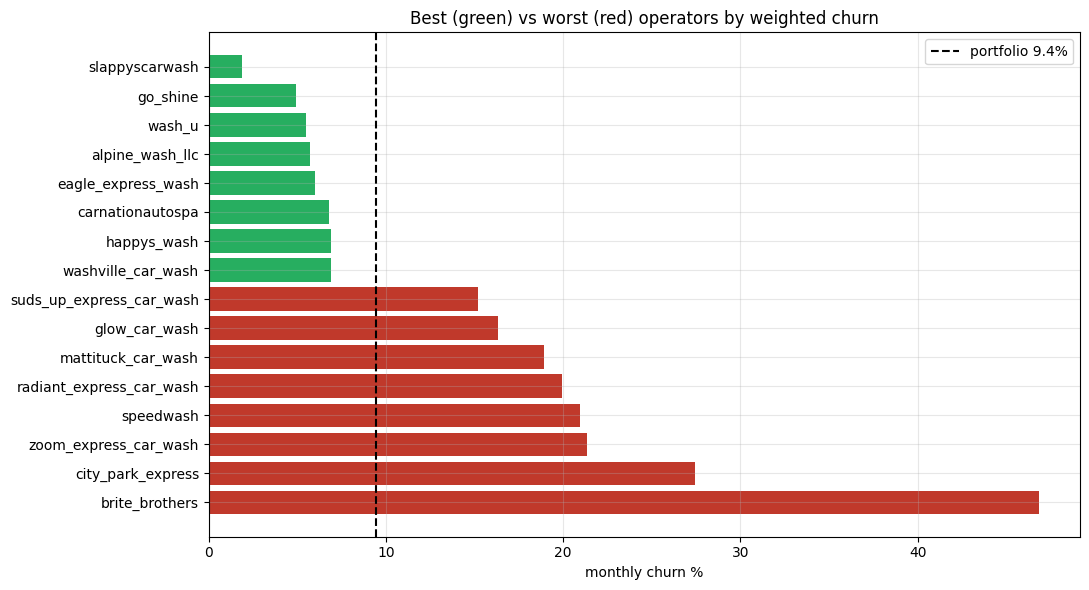

,weighted_churn_%,cum_accounts_start,locations
source_schema,,,
slappyscarwash,1.90,"125,784.00",4.00
go_shine,4.94,"244,901.00",6.00
wash_u,5.50,"1,402,340.00",32.00
alpine_wash_llc,5.69,"158,716.00",1.00
eagle_express_wash,6.01,"23,192.00",1.00
carnationautospa,6.80,"1,334,499.00",24.00
happys_wash,6.90,"180,105.00",7.00
washville_car_wash,6.90,"1,925,375.00",29.00
buckeye_super_wash,7.07,"27,577.00",1.00


In [20]:
op = (df.groupby('source_schema')
        .apply(lambda g: pd.Series({
            'weighted_churn_%': wchurn(g),
            'cum_accounts_start': g.accounts_start.sum(),
            'locations': g.location_name.nunique()}), include_groups=False)
        .query('cum_accounts_start > 5000')
        .sort_values('weighted_churn_%'))

fig, ax = plt.subplots(figsize=(11, 6))
rank = pd.concat([op.head(8), op.tail(8)])
colors = ['#27ae60']*8 + ['#c0392b']*8
ax.barh(rank.index, rank['weighted_churn_%'], color=colors)
ax.axvline(wchurn(df), color='k', ls='--', label=f'portfolio {wchurn(df):.1f}%')
ax.set(title='Best (green) vs worst (red) operators by weighted churn', xlabel='monthly churn %')
ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()
op.round(2)

## 7. Does scale protect against churn?

Yes — modestly. Larger membership bases churn lower. Using each location's most recent month, churn is negatively correlated with size (log accounts), and bigger-than-median locations churn ~1.3pp below smaller ones. Scale buys retention, but operator quality (Section 6) dominates.

corr(churn, log size) = -0.220
Median churn  large sites: 7.29%  |  small sites: 8.56%


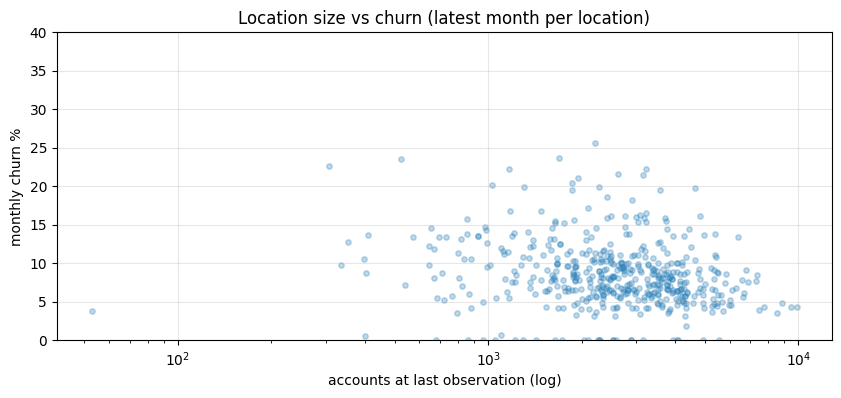

In [21]:
last = df.groupby('key').tail(1)
last = last[last.accounts_end > 50].copy()
last['churn_clip'] = last.churn_rate_accounts.clip(upper=100)

r = last['churn_clip'].corr(np.log(last.accounts_end))
big = last.accounts_end > last.accounts_end.median()
print(f'corr(churn, log size) = {r:.3f}')
print(f'Median churn  large sites: {last[big].churn_clip.median():.2f}%  |  '
      f'small sites: {last[~big].churn_clip.median():.2f}%')

plt.figure(figsize=(10, 4))
plt.scatter(last.accounts_end, last.churn_clip, alpha=.3, s=15, color='#2980b9')
plt.xscale('log'); plt.ylim(0, 40)
plt.xlabel('accounts at last observation (log)'); plt.ylabel('monthly churn %')
plt.title('Location size vs churn (latest month per location)'); plt.show()

## 8. Net membership growth (acquisition vs. churn)

The retention question that matters commercially: are signups outrunning cancellations? Over the trailing 12 months the portfolio is **still net-positive**, but the margin is thin — deactivations consume the large majority of gross adds, so retention improvement converts almost directly into net growth.

Trailing 12 months:
  gross signups   : 1,646,883
  deactivations   : 1,540,397
  net adds        : 106,486  (94% of adds lost to churn)


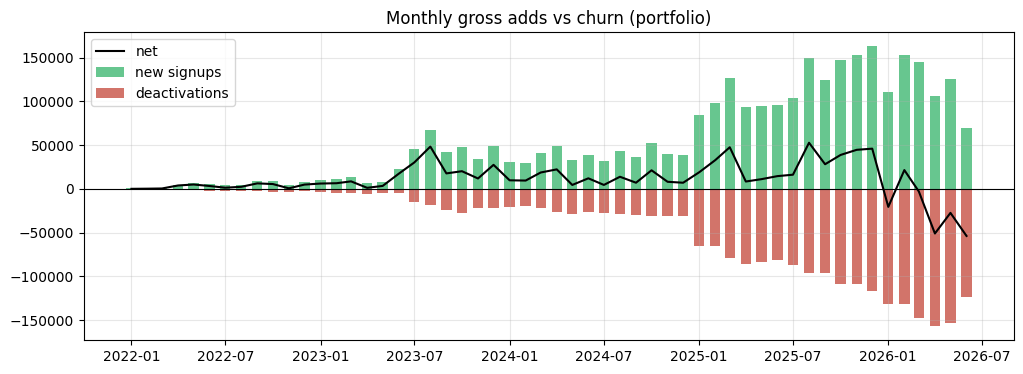

In [22]:
monthly = df.groupby('bucket_date')[['new_signups', 'deactivated_accounts']].sum()
monthly['net'] = monthly.new_signups - monthly.deactivated_accounts
recent = monthly.loc['2025-06-01':]

print('Trailing 12 months:')
print(f'  gross signups   : {recent.new_signups.sum():,.0f}')
print(f'  deactivations   : {recent.deactivated_accounts.sum():,.0f}')
print(f'  net adds        : {recent.net.sum():,.0f}  '
      f'({recent.deactivated_accounts.sum()/recent.new_signups.sum():.0%} of adds lost to churn)')

win = monthly.loc['2022-01-01':]
plt.figure(figsize=(12, 4))
plt.bar(win.index, win.new_signups, width=20, label='new signups', color='#27ae60', alpha=.7)
plt.bar(win.index, -win.deactivated_accounts, width=20, label='deactivations', color='#c0392b', alpha=.7)
plt.plot(win.index, win.net, 'k-', lw=1.5, label='net')
plt.axhline(0, color='k', lw=.8); plt.legend(); plt.title('Monthly gross adds vs churn (portfolio)')
plt.show()

## Key insights

1. **Use weighted churn, not the supplied rate.** `churn_rate_accounts` averages ~48% but is outlier-driven (small sites); true volume-weighted monthly churn is **~9.4%** (~70% annualized). 174 rows show >100% churn from tiny denominators.
2. **Mind the keys & units.** `location_id` is reused across operators — key on `source_schema | location_name` (~514 real sites). `active_members` != accounts; members are a superset, so this is *account* churn.
3. **No churn season.** Weighted churn is flat (8.4–10.1%) year-round; the apparent summer "spikes" are small-location noise. Signups, however, peak in spring and Aug/Oct.
4. **Honeymoon then peak.** Churn is lowest in a site's first ~2 months (~8%), peaks at months 3–5 (~11%) as launch-promo cohorts lapse, then settles ~10%. Target retention interventions at the 60–120 day mark.
5. **Growth-burst churn has normalized.** Churn spiked to 12.6% in 2023 during peak acquisition and has since settled to ~9% as the base matured past 13M members.
6. **Operator quality is the biggest lever.** Weighted churn ranges from <6% (best) to >20% (worst) — a far larger spread than seasonality, tenure, or scale. Benchmark and propagate best-operator playbooks.
7. **Scale helps modestly.** Larger sites churn ~1.3pp lower (corr ~ -0.22 with log size), but quality matters more than size.
8. **Net growth is positive but churn-bound.** Over the last 12 months deactivations consumed ~94% of gross signups — retention gains flow almost one-for-one into net growth.

**Data caveats:** the account-flow identity holds only ~66% of rows (positive residuals imply unmodeled reactivations/transfers); `churn_rate_*` has ~5% nulls; trust aggregates over single-row deltas.